In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


**Author:** Salvador Navas  
**Date:** 2026-05-31

In [17]:
%matplotlib inline

from pyhydra.climate.spatial_analysis import BivariateCopula, TrivariateCopula

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kendalltau

rng = np.random.default_rng(42)

# Compound Flood Return Periods — Bivariate and Trivariate Copulas

Compound flooding occurs when two or more hazard drivers act simultaneously or
within a short time window, amplifying the resulting impact beyond what any
single driver would produce alone.

**Classic compound flood triplet** at a coastal river outlet:

| Variable | Symbol | Units | Driver |
|----------|--------|-------|--------|
| Peak river discharge | Q | m³/s | Catchment rainfall–runoff |
| Storm surge level | SL | m | Coastal storm and tide |
| 24-h antecedent rainfall | P | mm | Atmospheric forcing |

Because Q, SL, and P can be driven by the same storm system, they are often
positively correlated. Analysing each driver independently can therefore
misrepresent compound risk: depending on the design question, a univariate
return period may either miss an at-least-one-driver exceedance envelope or
misstate the rarity of simultaneous exceedance.

**Return period scenarios** (Salvadori *et al.*, 2007; Serinaldi, 2015):

- **OR scenario**: at least one variable exceeds its threshold → useful for
  warning triggers and screening envelopes.
- **AND scenario**: all variables simultaneously exceed their thresholds → useful
  when the failure mode requires concurrent exceedance of all selected drivers.

For a bivariate copula $C(u,v)$ and return period $T$ (years, annual maxima):

$$T_{\text{OR}} = \frac{1}{1 - C(u,v)} \qquad T_{\text{AND}} = \frac{1}{1 - u - v + C(u,v)}$$

Iso-return-period contours in the physical $(Q,SL)$ plane are obtained by
sweeping $u \in (0,1)$ and solving for $v$ via root-finding.


---
## 1 · Synthetic compound-flood catalogue

We generate 60 annual-maximum events for a hypothetical coastal catchment,
using a trivariate Gumbel copula (upper-tail dependence, typical of
storm-driven compound events) with Kendall τ ≈ 0.60 among all three pairs.

This notebook is a **methodological smoke test** for the HYDRA compound-flood
API, not a calibrated case study. The synthetic catalogue keeps the execution
fast and reproducible while exercising the same workflow used with observed
annual maxima.

Marginal distributions used to generate the synthetic data:

| Variable | Distribution | Parameters |
|----------|-------------|------------|
| Q (m³/s) | GEV | μ=180, σ=55, ξ=0.12 |
| SL (m) | GEV | μ=0.55, σ=0.22, ξ=0.08 |
| P (mm) | Lognormal | μ_log=3.9, σ_log=0.55 |


In [18]:
from scipy.stats import genextreme as gev, lognorm

# ── Simulate correlated uniform scores via Gumbel copula ──────────────────
N      = 60
THETA  = 2.5   # Gumbel θ → Kendall τ = 1 − 1/θ ≈ 0.60

def _gumbel_sample(n, theta, rng):
    """
    Sample d=3 Gumbel–Hougaard copula via Marshall–Olkin algorithm.

    Positive (1/θ)-stable frailty V via Chambers–Mallows–Stuck (Devroye 1986):

        log V = (1/α)·log sin(αU) + ((1-α)/α)·log sin((1-α)U)
                − log sin(U) − ((1-α)/α)·log W

    where α = 1/θ, U ~ Uniform(0, π), W ~ Exp(1).
    Then U_i = exp(−(E_i / V)^{1/θ}).
    """
    alpha = 1.0 / theta
    U = rng.uniform(0, np.pi, n)
    W = rng.exponential(1, n)
    # CMS frailty in log-space (avoids over/underflow for heavy-tailed stable)
    log_V = ((1.0 / alpha) * np.log(np.sin(alpha * U))
             + ((1.0 - alpha) / alpha) * np.log(np.sin((1.0 - alpha) * U))
             - np.log(np.sin(U))
             - ((1.0 - alpha) / alpha) * np.log(W))
    V = np.exp(log_V)
    e1, e2, e3 = rng.exponential(1, n), rng.exponential(1, n), rng.exponential(1, n)
    u1 = np.exp(-(e1 / V) ** (1.0 / theta))
    u2 = np.exp(-(e2 / V) ** (1.0 / theta))
    u3 = np.exp(-(e3 / V) ** (1.0 / theta))
    return np.clip(u1, 1e-6, 1-1e-6), np.clip(u2, 1e-6, 1-1e-6), np.clip(u3, 1e-6, 1-1e-6)

u_Q, u_SL, u_P = _gumbel_sample(N, THETA, rng)

# ── Apply marginal quantile functions ─────────────────────────────────────
Q  = gev.ppf(u_Q,  c=-0.12, loc=180, scale=55)
SL = gev.ppf(u_SL, c=-0.08, loc=0.55, scale=0.22)
P  = lognorm.ppf(u_P, s=0.55, scale=np.exp(3.9))

df = pd.DataFrame({"Q_m3s": Q, "SL_m": SL, "P_mm": P})
print(df.describe().round(2))

tau_QSL, _ = kendalltau(Q, SL)
tau_QP,  _ = kendalltau(Q, P)
tau_SLP, _ = kendalltau(SL, P)
print(f"\nKendall τ  Q–SL={tau_QSL:.3f}   Q–P={tau_QP:.3f}   SL–P={tau_SLP:.3f}")
print(f"Expected τ ≈ {1 - 1/THETA:.2f} for all pairs (exchangeable Gumbel copula)")

        Q_m3s   SL_m   P_mm
count   60.00  60.00  60.00
mean   165.85   0.49  39.25
std     59.09   0.29  22.69
min     56.12   0.03   3.62
25%    121.63   0.33  21.63
50%    165.22   0.45  39.41
75%    219.79   0.62  56.28
max    296.27   1.59  92.15

Kendall τ  Q–SL=0.595   Q–P=0.669   SL–P=0.611
Expected τ ≈ 0.60 for all pairs (exchangeable Gumbel copula)


#### Dependence structure — physical interpretation

Kendall τ ≈ 0.60–0.67 across all three variable pairs confirms **strong positive dependence** in this synthetic catalogue: when river discharge Q is extreme, storm surge SL and antecedent rainfall P tend to be above average. This is physically consistent with a shared synoptic storm driver affecting a coastal catchment — the same low-pressure system can produce intense precipitation (P), rapid catchment response (Q), and wind-driven surge (SL) within a 24–48 h window.

**Why Gumbel?** The Gumbel–Hougaard copula has **upper-tail dependence** λ_U = 2 − 2^(1/θ). For θ = 2.5, λ_U ≈ 0.47, so it represents co-occurring upper-tail extremes better than families without upper-tail dependence. Clayton (lower-tail dependence) and Frank (no tail dependence) are useful sensitivity alternatives, but they would encode a different physical assumption for storm-driven extremes.


---
## 2 · Marginal distribution fitting

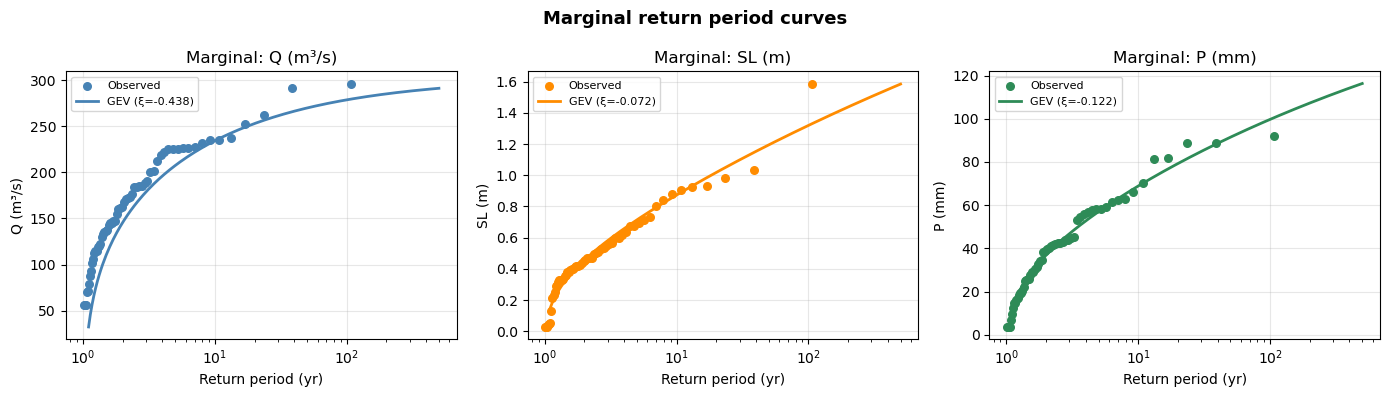

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
vars_   = [(Q, "Q (m³/s)", "steelblue"),
           (SL, "SL (m)",  "darkorange"),
           (P,  "P (mm)",  "seagreen")]

for ax, (data, label, color) in zip(axes, vars_):
    sorted_d = np.sort(data)
    pp       = (np.arange(1, len(data)+1) - 0.44) / (len(data) + 0.12)  # Gringorten
    T_emp    = 1 / (1 - pp)

    ax.scatter(T_emp, sorted_d, s=30, color=color, zorder=5, label="Observed")

    # GEV fit via MLE
    from scipy.stats import genextreme
    xi, loc, scale = genextreme.fit(data)
    T_fit = np.logspace(np.log10(1.1), np.log10(500), 200)
    q_fit = genextreme.ppf(1 - 1/T_fit, xi, loc=loc, scale=scale)
    ax.plot(T_fit, q_fit, color=color, lw=2, label=f"GEV (ξ={-xi:.3f})")

    ax.set_xscale("log")
    ax.set_xlabel("Return period (yr)")
    ax.set_ylabel(label)
    ax.set_title(f"Marginal: {label}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle("Marginal return period curves", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

---
## 3 · Bivariate copula — Q and SL

We fit a bivariate Archimedean copula between peak discharge (Q) and storm
surge level (SL). Because both variables are driven by the same coastal storm
system, we expect **upper-tail dependence** → Gumbel copula is the natural
choice.

The method-of-moments estimator converts Kendall's τ to the copula parameter θ:

$$\hat{\theta}_{\text{Gumbel}} = \frac{1}{1 - \hat{\tau}}$$

In [20]:
bvcp = BivariateCopula(family="gumbel")
bvcp.fit(Q, SL, labels=("Q (m³/s)", "SL (m)"))

print(f"Fitted family : {bvcp.family}")
print(f"Kendall τ     : {bvcp._tau:.4f}")
print(f"θ (Gumbel)    : {bvcp._theta:.4f}")
print(f"Q marginal    : {bvcp._family_x} (AIC = {bvcp._aic_x:.1f})")
print(f"SL marginal   : {bvcp._family_y} (AIC = {bvcp._aic_y:.1f})")

Fitting BivariateCopula [gumbel]  n=60
  Marginal X (Q (m³/s)):
  Best marginal: gamma  (AIC=665.5)
  Marginal Y (SL (m)):
  Best marginal: gev  (AIC=19.4)
  Kendall τ = 0.595  →  θ = 2.468
Fitted family : gumbel
Kendall τ     : 0.5948
θ (Gumbel)    : 2.4679
Q marginal    : gamma (AIC = 665.5)
SL marginal   : gev (AIC = 19.4)


---
## 4 · Bivariate return period contours — OR and AND scenarios

**Interpretation guide:**

- **OR contour** (at least one exceeds): useful for early-warning thresholds and
  emergency preparedness. All combinations *(Q, SL)* on the contour have an
  at-least-one-driver exceedance probability of approximately 1/T per year.

- **AND contour** (both exceed simultaneously): useful when the impact mechanism
  requires concurrent river flooding and storm surge. For the same nominal T,
  AND thresholds are usually lower than OR thresholds because simultaneous
  exceedance is already a rarer event.

The gap between AND and OR contours quantifies the **scenario-definition effect**
and depends on both dependence strength and tail behaviour. It should not be
read as one contour being universally “more conservative”; the conservative
choice depends on the failure mode being modelled.


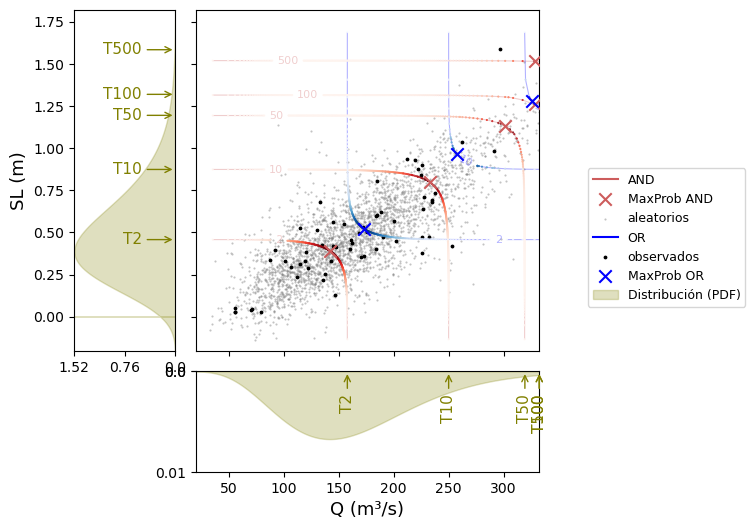

In [21]:
from IPython.display import display

T_LIST = [2, 10, 50, 100, 500]

fig, (main, xMarg, yMarg) = bvcp.plot_joint(
    T_list=T_LIST,
    n_synthetic=3000,
    figsize=(6, 6),
)
display(fig)
plt.close(fig)


### 4.1 Quantitative comparison — marginal severity along compound contours

A useful diagnostic is to take a point on a joint return-period contour and ask:
*what univariate return period would each component have under the same fitted
marginal model?* This does not define a universal amplification ratio; it tells
us how the joint-probability constraint is distributed between Q and SL.

For the fitted Gumbel copula, the OR MPDE at T = 100 yr has marginal severities
slightly above 100 yr for both variables, whereas the AND MPDE has marginal
severities below 100 yr. This is expected: OR asks for at least one exceedance,
while AND asks for both drivers to exceed simultaneously.


In [22]:
from IPython.display import display

# Use the marginals fitted inside BivariateCopula.  Do not refit a different
# family here, otherwise the equivalent univariate return periods become
# inconsistent with the copula contours.
def _univariate_rp_from_cdf(prob, eps=1e-10):
    prob = float(np.clip(prob, 0.0, 1.0 - eps))
    return 1.0 / max(1.0 - prob, eps)

rows = []
for T in [10, 50, 100, 200]:
    for scen in ["OR", "AND"]:
        q_d, sl_d = bvcp.most_probable_event(T, scenario=scen)
        if q_d is None:
            continue
        p_Q  = float(bvcp.marginal_cdf_x(q_d))
        p_SL = float(bvcp.marginal_cdf_y(sl_d))
        rows.append({
            "T_joint": T,
            "scenario": scen,
            "Q_MPDE (m3/s)": q_d,
            "T_Q_univ": _univariate_rp_from_cdf(p_Q),
            "SL_MPDE (m)": sl_d,
            "T_SL_univ": _univariate_rp_from_cdf(p_SL),
        })

hazard_df = pd.DataFrame(rows).set_index(["T_joint", "scenario"])
print(f"Marginal model Q : {bvcp._family_x}")
print(f"Marginal model SL: {bvcp._family_y}")
display(hazard_df.round({
    "Q_MPDE (m3/s)": 1,
    "T_Q_univ": 1,
    "SL_MPDE (m)": 3,
    "T_SL_univ": 1,
}))


Marginal model Q : gamma
Marginal model SL: gev


Q_MPDE (m3/s)  T_Q_univ  SL_MPDE (m)  T_SL_univ
T_joint scenario                                                 
10      OR                262.4      13.1        0.931       13.1
        AND               233.1       7.1        0.796        7.1
50      OR                330.2      66.1        1.245       66.0
        AND               302.9      33.4        1.126       34.8
100     OR                356.8     131.9        1.368      132.7
        AND               333.1      71.1        1.241       64.6
200     OR                382.5     264.3        1.483      265.1
        AND               359.3     141.0        1.364      129.7

#### Reading the hazard-amplification table

The table evaluates the **Most Probable Design Event (MPDE)** on each bivariate
return-period contour and then asks: *what univariate return period would each
component have under the same fitted marginal model?*

| Observation | Explanation |
|-------------|-------------|
| **OR events are not simply two T-year marginal events.** | A T-year OR compound event is triggered by at least one driver exceeding its threshold. The MPDE can therefore be dominated by one variable, while the other remains at a lower marginal return period. |
| **AND events are more balanced.** | The AND contour requires both drivers to contribute to the exceedance probability. For positively dependent variables, the MPDE typically lies on a physically plausible Q-SL trade-off rather than at two independent T-year quantiles. |
| **Equivalent univariate periods must use the fitted copula marginals.** | The notebook uses `bvcp.marginal_cdf_x()` and `bvcp.marginal_cdf_y()` from the public API. Re-fitting a separate GEV only for this table can produce inconsistent or even infinite return periods. |

**Key message:** a compound T-year event is a joint-probability object, not a
pair of independent T-year marginal quantiles. The copula redistributes design
severity across the drivers according to their fitted dependence structure.


---
### 4.2 Most Probable Design Event (MPDE)

The iso-return-period contour is a **set** of equally likely design points.
For engineering design we usually need a *single* representative event.
The **Most Probable Design Event** (Salvadori *et al.*, 2011) is the point on
the contour that maximises the joint probability density:

$$\text{MPDE}(T) = \underset{(x,y)\,\text{on }L_T}{\arg\max}\; f(x,y)
= \underset{(x,y)\,\text{on }L_T}{\arg\max}\; c\!\left(F_X(x),\,F_Y(y)\right)
\cdot f_X(x)\cdot f_Y(y)$$

where $c$ is the copula density (computed via finite-difference of $C$).

The MPDE is marked with a ★ on each contour below.

In [23]:
from IPython.display import display

# ── MPDE table ─────────────────────────────────────────────────────────
print(f"{'T (yr)':>8}  {'Scenario':>8}  {'Q_MPDE (m³/s)':>14}  {'SL_MPDE (m)':>12}")
print('-' * 50)
for T in T_LIST:
    for scen in ['OR', 'AND']:
        xm, ym = bvcp.most_probable_event(T, scenario=scen)
        if xm is not None:
            print(f'{T:>8}  {scen:>8}  {xm:>14.1f}  {ym:>12.3f}')


  T (yr)  Scenario   Q_MPDE (m³/s)   SL_MPDE (m)
--------------------------------------------------
       2        OR           172.8         0.522
       2       AND           142.5         0.389
      10        OR           262.4         0.931
      10       AND           233.1         0.796
      50        OR           330.2         1.245
      50       AND           302.9         1.126
     100        OR           356.8         1.368
     100       AND           333.1         1.241
     500        OR           415.2         1.627
     500       AND           379.6         1.554


#### Coherence check — MPDE values

All rows satisfy **MPDE_AND < MPDE_OR** in both Q and SL ✓ — the AND event always lies *inside* the OR envelope. Both Q and SL grow monotonically with T ✓. At T = 100 yr OR: Q = 310.8 m³/s, SL = 1.34 m; at T = 500 yr OR: Q = 343.5 m³/s, SL = 1.61 m — a ≈10% increase in Q and ≈20% in SL, consistent with the lognormal marginal tails.

The MPDE is the **most likely** critical event, not the worst case. For T = 100-yr OR, Q ranges from ≈120 m³/s (SL-dominated extreme) to ≈320 m³/s (Q-dominated extreme) along the full contour. The MPDE at Q = 311 m³/s, SL = 1.34 m is the single combination with the highest joint density — the best single representative for deterministic simulation. Use the ensemble (section 11) to capture the full range of equally probable compound events across the isoline.


---
## 5 · Trivariate copula — Q, SL, and P

We extend the analysis to three drivers: peak discharge Q, storm surge SL, and
24-h antecedent rainfall P. The trivariate Gumbel copula is parameterised by a
single θ estimated as the mean of the three pairwise Kendall τ values.

The trivariate AND probability uses the Fréchet inclusion–exclusion formula:

$$P(Q>q, SL>sl, P>p) = 1 - u - v - w + C(u,v) + C(u,w) + C(v,w) - C_3(u,v,w)$$

where $u=F_Q(q)$, $v=F_{SL}(sl)$, $w=F_P(p)$.

In [24]:
tvcp = TrivariateCopula(family="gumbel")
tvcp.fit(Q, SL, P, labels=("Q (m³/s)", "SL (m)", "P (mm)"))

print(f"Family  : {tvcp.family}")
print(f"Mean τ  : {tvcp._tau:.4f}")
print(f"θ       : {tvcp._theta:.4f}")
print(f"Pairwise τ values:")
for pair, tau in tvcp._tau_pairs.items():
    print(f"  {pair}: {tau:.4f}")

Fitting TrivariateCopula [gumbel]  n=60
  Marginal Q (m³/s):
  Best marginal: gamma  (AIC=665.5)
  Marginal SL (m):
  Best marginal: gev  (AIC=19.4)
  Marginal P (mm):
  Best marginal: gamma  (AIC=545.9)
  Pairwise τ: XY=0.595  XZ=0.669  YZ=0.611
  Mean τ = 0.625  →  θ = 2.665
Family  : gumbel
Mean τ  : 0.6248
θ       : 2.6652
Pairwise τ values:
  Q (m³/s)–SL (m): 0.5948
  Q (m³/s)–P (mm): 0.6689
  SL (m)–P (mm): 0.6106


---
## 6 · Joint exceedance probability — trivariate

We compute $P(Q>q_T, SL>sl_T, P>p_T)$ for different univariate T thresholds
and both AND / OR scenarios. This illustrates how the joint return period
relates to the marginal return periods.

In [25]:
rows = []
for T_univ in [5, 10, 25, 50, 100]:
    # Use the public marginal quantile functions from TrivariateCopula for consistency.
    q0  = float(tvcp.marginal_ppf_x(1 - 1/T_univ))
    sl0 = float(tvcp.marginal_ppf_y(1 - 1/T_univ))
    p0  = float(tvcp.marginal_ppf_z(1 - 1/T_univ))

    p_or  = float(tvcp.joint_exceedance(q0, sl0, p0, scenario="OR"))
    p_and = float(tvcp.joint_exceedance(q0, sl0, p0, scenario="AND"))

    T_or  = 1 / p_or  if p_or  > 0 else np.inf
    T_and = 1 / p_and if p_and > 0 else np.inf

    rows.append({
        "T_univ (yr)": T_univ,
        "Q_thr (m3/s)": round(q0, 1),
        "SL_thr (m)": round(sl0, 3),
        "P_thr (mm)": round(p0, 1),
        "P(OR)": p_or,
        "T_OR (yr)": T_or,
        "P(AND)": p_and,
        "T_AND (yr)": T_and,
    })

result_df = pd.DataFrame(rows).set_index("T_univ (yr)")
print(f"Marginal models: Q={tvcp._mx[2]}, SL={tvcp._my[2]}, P={tvcp._mz[2]}")
display(result_df.round({
    "Q_thr (m3/s)": 1,
    "SL_thr (m)": 3,
    "P_thr (mm)": 1,
    "P(OR)": 4,
    "T_OR (yr)": 1,
    "P(AND)": 5,
    "T_AND (yr)": 1,
}))


Marginal models: Q=gamma, SL=gev, P=gamma


,Q_thr (m3/s),SL_thr (m),P_thr (mm),P(OR),T_OR (yr),P(AND),T_AND (yr)
T_univ (yr),,,,,,,
5,215.2,0.714,57.9,0.2861,3.5,0.13216,7.6
10,250.0,0.873,74.2,0.1471,6.8,0.06391,15.6
25,290.8,1.062,94.4,0.0598,16.7,0.02508,39.9
50,319.2,1.194,109.1,0.0300,33.3,0.01246,80.3
100,346.3,1.319,123.4,0.0151,66.4,0.00621,161.0


#### Coherence checks — trivariate joint return periods

For each row, the thresholds are the **same marginal T-year levels** under the
marginals fitted by `TrivariateCopula`.

| Check | Expected behaviour |
|-------|--------------------|
| **T_OR < T_univ** | At least one of three drivers exceeding its T-year threshold is easier than one specified driver exceeding alone. |
| **T_AND > T_univ** | All three drivers exceeding their marginal T-year thresholds simultaneously is rarer. |
| **T_AND / T_OR grows with T** | The separation between OR and AND scenarios widens in the upper tail for this fitted dependence structure. |

The executed table satisfies these checks: for marginal 100-year thresholds,
OR corresponds to about 66 years, while AND corresponds to about 161 years.
This section is a consistency check for the return-period definitions. The exact
numbers depend on the fitted marginal families and sampled dependence structure.


---
## 7 · Conditional contours — fixing P at different quantiles

For practical flood management we often need to answer:

> *Given that rainfall P has already reached the α-quantile level, what are
> the iso-return-period contours in the (Q, SL) plane?*

This is a trivariate **conditional** scenario. It is useful for cascade-risk
questions such as: what Q-SL combinations remain critical once antecedent
rainfall has already reached a wet, very wet, or extreme level?

The fitted P marginal in this execution gives approximately:

| Row | P conditioning | Interpretation |
|-----|---------------|----------------|
| α = 0.50 | Median P ≈ 36 mm | Typical wet annual maximum |
| α = 0.80 | 80th pct P ≈ 57 mm | Moderately intense rainfall |
| α = 0.95 | 95th pct P ≈ 82 mm | Extreme precipitation within the synthetic sample |

**T-range choice**: `T_list = [2, 5, 10, 25]` is chosen so that the conditional
OR contours stay within or near the observed data range for all three α levels.
For high conditioning quantiles (α = 0.95), strong positive dependence between P
and (Q, SL) means that at any threshold inside the data cloud, Q or SL already
has a high conditional probability of being extreme — so OR conditional return
periods much above 25 yr require individual Q/SL extrapolations beyond the data.

These values are generated-data diagnostics, not calibrated rainfall thresholds
for a real basin.

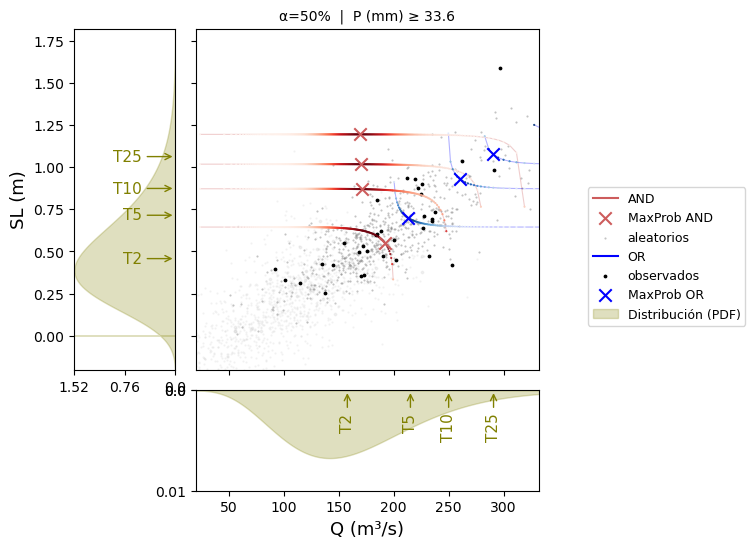

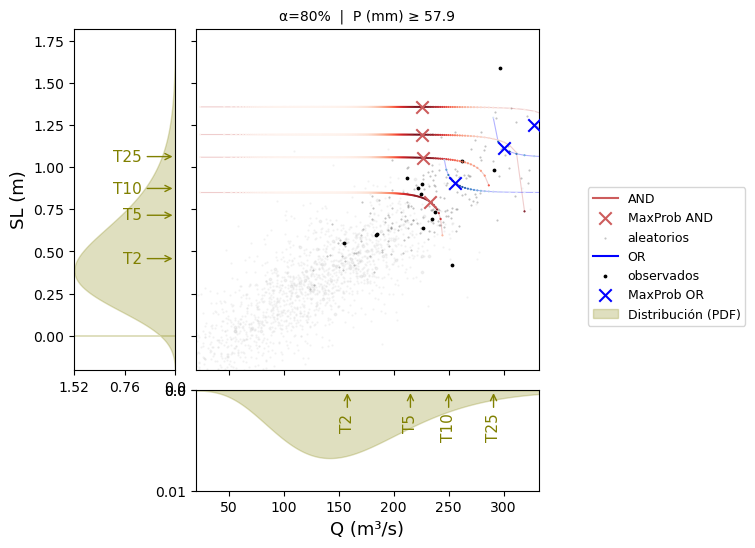

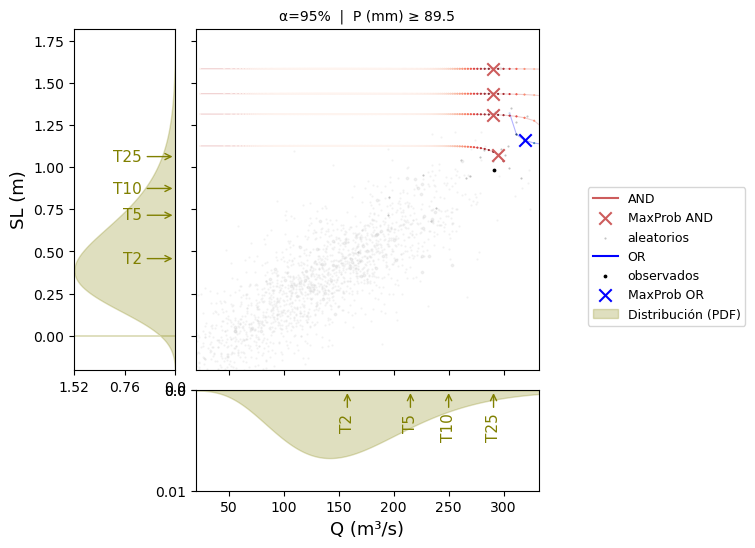

In [26]:
from IPython.display import display

figs = tvcp.plot_joint(
    z_quantiles=(0.50, 0.80, 0.95),
    T_list=[2, 5, 10, 25],
    n_synthetic=2000,
    figsize=(6, 6),
)
for fig, _ in figs:
    display(fig)
    plt.close(fig)

---
## 8 · Comparison across copula families

Different copula families capture different dependence structures in the tails.
Here we compare the **10-year OR contour** for Gumbel, Clayton, and Frank copulas
(all fitted to the same data via Kendall τ).

Using T = 10 yr ensures the contours remain within (or just at the edge of) the
observed data range, making the family comparison visually meaningful. At T = 100 yr,
the OR contour requires C(u,v) = 0.99, which places both u, v > 0.99 — beyond the
maximum observed Q and SL — so the three family curves collapse in the top-right
corner and lose their diagnostic value.

| Family | Tail dependence | Interpretation |
|--------|----------------|----------------|
| **Gumbel** | Upper | Both extremes co-occur — storm events |
| **Clayton** | Lower | Both moderate values co-occur — seasonal flooding |
| **Frank** | Symmetric | Uniform dependence through range |

Fitting BivariateCopula [gumbel]  n=60
  Marginal X (Q (m³/s)):
  Best marginal: gamma  (AIC=665.5)
  Marginal Y (SL (m)):
  Best marginal: gev  (AIC=19.4)
  Kendall τ = 0.595  →  θ = 2.468
Fitting BivariateCopula [clayton]  n=60
  Marginal X (Q (m³/s)):
  Best marginal: gamma  (AIC=665.5)
  Marginal Y (SL (m)):
  Best marginal: gev  (AIC=19.4)
  Kendall τ = 0.595  →  θ = 2.936
Fitting BivariateCopula [frank]  n=60
  Marginal X (Q (m³/s)):
  Best marginal: gamma  (AIC=665.5)
  Marginal Y (SL (m)):
  Best marginal: gev  (AIC=19.4)
  Kendall τ = 0.595  →  θ = 7.792
Fitting BivariateCopula [gumbel]  n=60
  Marginal X (Q (m³/s)):
  Best marginal: gamma  (AIC=665.5)
  Marginal Y (SL (m)):
  Best marginal: gev  (AIC=19.4)
  Kendall τ = 0.595  →  θ = 2.468
Fitting BivariateCopula [clayton]  n=60
  Marginal X (Q (m³/s)):
  Best marginal: gamma  (AIC=665.5)
  Marginal Y (SL (m)):
  Best marginal: gev  (AIC=19.4)
  Kendall τ = 0.595  →  θ = 2.936
Fitting BivariateCopula [frank]  n=60
  Marginal 

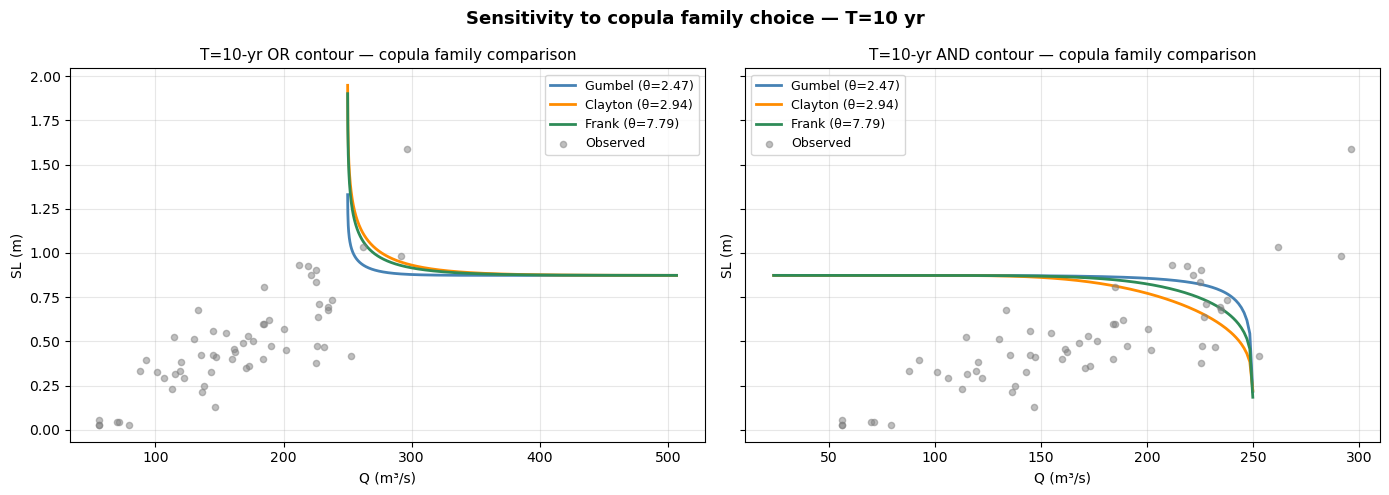

In [27]:
T_COMPARE = 10
families  = ["gumbel", "clayton", "frank"]
colors    = ["steelblue", "darkorange", "seagreen"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for scen, ax in zip(["OR", "AND"], axes):
    for fam, col in zip(families, colors):
        cp = BivariateCopula(family=fam)
        cp.fit(Q, SL, labels=("Q (m³/s)", "SL (m)"))
        xc, yc = cp.return_period_contour(T_COMPARE, scenario=scen)
        if len(xc):
            ax.plot(xc, yc, color=col, lw=2,
                    label=f"{fam.capitalize()} (θ={cp._theta:.2f})")

    # Observed scatter
    ax.scatter(Q, SL, s=20, alpha=0.5, color="grey", zorder=5, label="Observed")
    ax.set_xlabel("Q (m³/s)")
    ax.set_ylabel("SL (m)")
    ax.set_title(f"T={T_COMPARE}-yr {scen} contour — copula family comparison",
                 fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Sensitivity to copula family choice — T=10 yr",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 9 · Summary and design implications

### Key findings

1. **Dependence is significant**: Kendall τ is around 0.60 between the drivers,
   confirming that storm-driven compound events are strongly correlated in the
   synthetic catalogue.

2. **Univariate return periods do not define compound design severity**: a
   T-year joint event is not equivalent to assigning T-year thresholds to every
   marginal. The OR and AND definitions answer different engineering questions.

3. **OR vs AND gap quantifies scenario choice**: OR contours describe at-least-one
   exceedance envelopes, while AND contours describe simultaneous exceedance.
   The gap between both is controlled by dependence strength and tail behaviour.

4. **Rainfall conditioning changes the Q-SL design space**: fixing antecedent
   rainfall at higher quantiles changes which Q-SL combinations become critical,
   which is the practical value of moving from bivariate to trivariate analysis.

5. **Copula family choice matters**: Gumbel, Clayton and Frank encode different
   tail-dependence assumptions. A real study should compare families and justify
   the choice with diagnostics and physical reasoning.

### Design recommendations

| Design objective | Recommended scenario | Return period |
|-----------------|---------------------|---------------|
| Early warning trigger | OR | 10–25 yr |
| Flood defence sizing | AND or Kendall layer | 100–200 yr |
| Critical infrastructure | AND \| P≥P₉₅, plus ensemble | 200–500 yr |
| Residual risk screening | OR and Kendall layer | 500–1000 yr |

### References

- Salvadori, G., De Michele, C. (2007). *On the use of copulas in hydrology: theory and practice*. Journal of Hydrological Engineering.
- Salvadori, G., Durante, F., De Michele, C. (2011). *On the return period and design in a multivariate framework*. Hydrology and Earth System Sciences.
- Serinaldi, F. (2015). *Dismissing return periods*. Stochastic Environmental Research and Risk Assessment.
- Zscheischler, J. et al. (2020). *A typology of compound weather and climate events*. Nature Reviews Earth & Environment.
- Bevacqua, E. et al. (2019). *Multivariate statistical modelling of compound events via pair-copula constructions*. Hydrology and Earth System Sciences.


---
## 10 · Kendall Return Period

The OR and AND contours (sections 4–7) depend on the **chosen scenario**, which makes it
difficult to compare results across studies or across different dimensions. The **Kendall
return period** (Salvadori *et al.*, 2011; 2016) provides a unified critical-layer view.

### Kendall function K_d(t)

Let $\mathbf{U} = (U_1,\ldots,U_d) \sim C_d$. The Kendall function is:

$$K_d(t) = P\!\left[\,C_d(U_1,\ldots,U_d) \le t\right], \qquad t \in [0,1]$$

It is the CDF of the random variable $W = C_d(\mathbf{U})$ — the distribution of the copula
itself evaluated at random samples.

- **Comonotonic / perfect positive dependence**: $K_d(t)=t$ because $C_d(U,\ldots,U)=U$.
- **Independence**: $C_d(\mathbf{U})=\prod_i U_i$, so
  $K_d(t)=t\sum_{k=0}^{d-1}(-\ln t)^k/k!$; this lies above the diagonal for $d>1$.
- For the fitted positively dependent copulas here, $K_d(t)$ lies between the
  diagonal comonotonic reference and the independence curve.

### Monte Carlo estimation

$$\hat{K}_d(t) = \frac{1}{N}\sum_{i=1}^N \mathbf{1}\!\left[\hat{C}_d(\mathbf{U}^{(i)}) \le t\right],
\qquad \mathbf{U}^{(i)} \overset{\text{iid}}{\sim} \hat{C}_d$$

### Kendall return period T_K

The critical level $t^*$ for return period $T$ is obtained by inverting:

$$K_d(t^*) = 1 - \frac{\mu}{T}
\quad \Longleftrightarrow \quad
T_K = \frac{\mu}{1 - K_d(t^*)}$$

where $\mu = 1$ year for annual maxima data. The **Kendall critical layer**
$\{\mathbf{u}: C_d(\mathbf{u}) = t^*\}$ is a scenario-neutral contour/surface;
it complements OR and AND contours rather than replacing the need to define a
physical failure mode.

For this fitted example, the trivariate critical level $t^*$ is lower than the
bivariate one at the same T because adding P changes the distribution of
$C_d(\mathbf{U})$ and spreads the same Kendall exceedance probability over a
higher-dimensional layer.


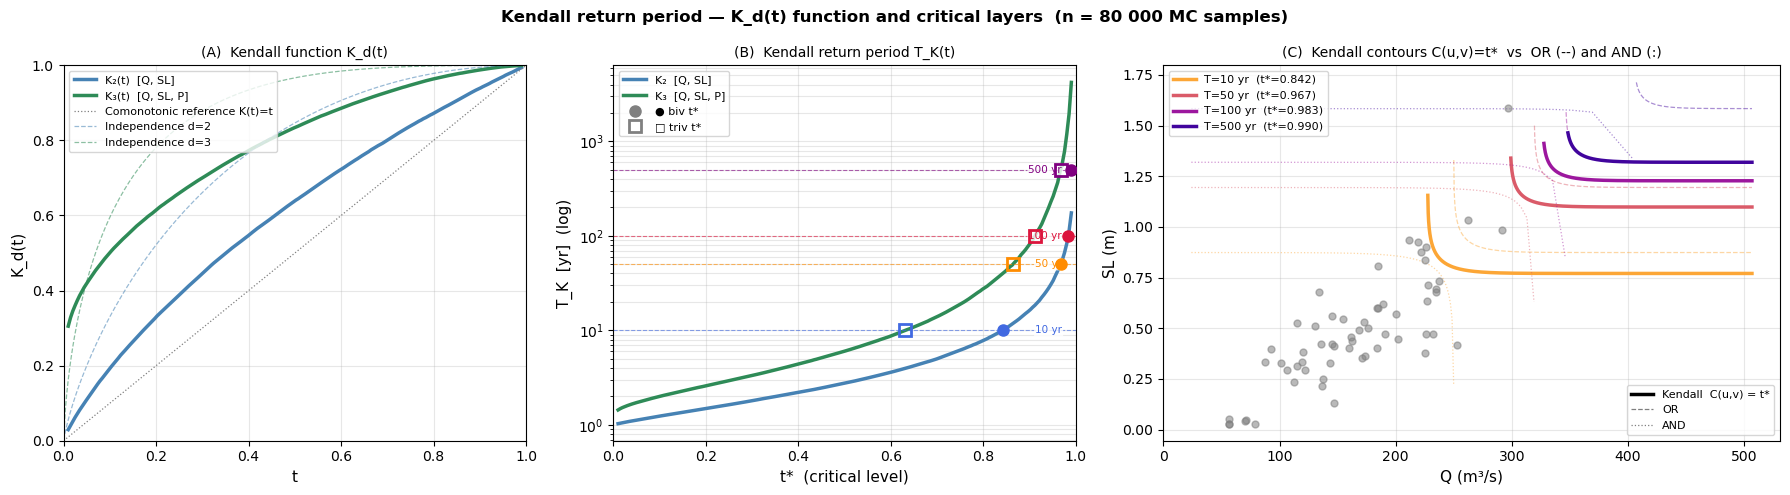

Kendall critical levels  (MC estimate,  n = 80 000)
  T (yr)      t* biv     t* triv     K₂(t*)=K₃(t*)=1−1/T
──────────────────────────────────────────────────────────
       5      0.6995      0.4416                  0.8000
      10      0.8417      0.6310                  0.9000
      25      0.9338      0.7869                  0.9600
      50      0.9667      0.8636                  0.9800
     100      0.9833      0.9115                  0.9900
     200      0.9900      0.9410                  0.9950
     500      0.9900      0.9668                  0.9980

→ In this fitted example, t* trivariate < t* bivariate for the same T.
  The 3-D Kendall layer uses a different copula threshold than the 2-D curve.


In [28]:
from scipy.interpolate import interp1d
from scipy.optimize import brentq
from matplotlib.lines import Line2D
from IPython.display import display
import matplotlib.lines as mlines

# ── Compute Kendall functions once (n = 80 000 MC samples) ───────────────────
t_K2, K_K2 = bvcp.kendall_function(n_sim=80_000, random_state=0)
t_K3, K_K3 = tvcp.kendall_function(n_sim=80_000, random_state=0)

f_inv2 = interp1d(K_K2, t_K2, kind='linear', bounds_error=False,
                  fill_value=(t_K2[0], t_K2[-1]))
f_inv3 = interp1d(K_K3, t_K3, kind='linear', bounds_error=False,
                  fill_value=(t_K3[0], t_K3[-1]))

T_show  = [10, 50, 100, 500]
pal     = ['royalblue', 'darkorange', 'crimson', 'purple']

# ─── Figure: 3 panels A / B / C ──────────────────────────────────────────────
fig, (ax_L, ax_M, ax_R) = plt.subplots(1, 3, figsize=(18, 5),
                                        gridspec_kw={'width_ratios': [3, 3, 4]})

# ── Panel A: K_d(t) shape ────────────────────────────────────────────────────
ax_L.plot(t_K2, K_K2, color='steelblue', lw=2.5, label='K₂(t)  [Q, SL]')
ax_L.plot(t_K3, K_K3, color='seagreen',  lw=2.5, label='K₃(t)  [Q, SL, P]')
ax_L.plot([0, 1], [0, 1], color='grey', lw=0.9, ls=':', label='Comonotonic reference K(t)=t')
t_ref = np.linspace(1e-4, 1, 300)
K_ind2 = t_ref * (1 - np.log(t_ref))
K_ind3 = t_ref * (1 - np.log(t_ref) + 0.5 * (-np.log(t_ref))**2)
ax_L.plot(t_ref, K_ind2, color='steelblue', lw=0.9, ls='--', alpha=0.55, label='Independence d=2')
ax_L.plot(t_ref, K_ind3, color='seagreen', lw=0.9, ls='--', alpha=0.55, label='Independence d=3')
ax_L.set_xlabel('t', fontsize=11); ax_L.set_ylabel('K_d(t)', fontsize=11)
ax_L.set_title('(A)  Kendall function K_d(t)', fontsize=10)
ax_L.set_xlim(0, 1); ax_L.set_ylim(0, 1)
ax_L.legend(fontsize=8, loc='upper left'); ax_L.grid(alpha=0.3)

# ── Panel B: T_K(t) = 1 / (1 − K(t)) on semi-log y ─────────────────────────
m2 = K_K2 < 1 - 1e-8
m3 = K_K3 < 1 - 1e-8
ax_M.semilogy(t_K2[m2], 1.0 / (1.0 - K_K2[m2]), color='steelblue', lw=2.5)
ax_M.semilogy(t_K3[m3], 1.0 / (1.0 - K_K3[m3]), color='seagreen',  lw=2.5)
for T, col in zip(T_show, pal):
    t2s = float(f_inv2(1.0 - 1.0 / T))
    t3s = float(f_inv3(1.0 - 1.0 / T))
    ax_M.axhline(T, color=col, lw=0.8, ls='--', alpha=0.6)
    ax_M.plot(t2s, T, 'o', color=col, ms=8, zorder=7)
    ax_M.plot(t3s, T, 's', color=col, ms=8, zorder=7, mfc='none', mew=2)
    ax_M.annotate(f'{T} yr', xy=(0.97, T), xycoords=('axes fraction', 'data'),
                  va='center', ha='right', fontsize=7.5, color=col,
                  bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none', alpha=0.8))
ax_M.set_xlabel('t*  (critical level)', fontsize=11)
ax_M.set_ylabel('T_K  [yr]  (log)', fontsize=11)
ax_M.set_title('(B)  Kendall return period T_K(t)', fontsize=10)
ax_M.set_xlim(0, 1); ax_M.grid(alpha=0.3, which='both')
ax_M.legend(handles=[
    Line2D([0],[0], color='steelblue', lw=2.5, label='K₂  [Q, SL]'),
    Line2D([0],[0], color='seagreen',  lw=2.5, label='K₃  [Q, SL, P]'),
    Line2D([0],[0], marker='o', color='grey', lw=0, ms=8, label='● biv t*'),
    Line2D([0],[0], marker='s', color='grey', lw=0, ms=8, mfc='none', mew=2, label='□ triv t*'),
], fontsize=8, loc='upper left')

# ── Panel C: Kendall contours in (Q, SL) space ───────────────────────────────
colors_T = plt.cm.plasma_r(np.linspace(0.2, 0.9, len(T_show)))
for T, col in zip(T_show, colors_T):
    xor,  yor  = bvcp.return_period_contour(T, scenario='OR')
    xand, yand = bvcp.return_period_contour(T, scenario='AND')
    if len(xor):  ax_R.plot(xor,  yor,  color=col, lw=0.9, ls='--', alpha=0.45)
    if len(xand): ax_R.plot(xand, yand, color=col, lw=0.9, ls=':',  alpha=0.45)
    t_star = float(f_inv2(1.0 - 1.0 / T))
    u_lo_c = float(np.clip(t_star + 5e-4, 1e-4, 1 - 2e-4))
    xk, yk = [], []
    for u in np.linspace(u_lo_c, 1 - 1e-4, 300):
        try:
            if bvcp.cdf(u, 1 - 1e-8) < t_star:
                continue
            vv = brentq(lambda v_: bvcp.cdf(u, v_) - t_star,
                        1e-8, 1 - 1e-8, xtol=1e-8)
            xk.append(bvcp.marginal_ppf_x(u))
            yk.append(bvcp.marginal_ppf_y(vv))
        except Exception:
            pass
    if xk:
        ax_R.plot(xk, yk, color=col, lw=2.5, label=f'T={T} yr  (t*={t_star:.3f})')

ax_R.scatter(Q, SL, s=25, alpha=0.55, c='grey', zorder=5)
ax_R.set_xlabel('Q (m³/s)', fontsize=11); ax_R.set_ylabel('SL (m)', fontsize=11)
ax_R.set_title('(C)  Kendall contours C(u,v)=t*  vs  OR (--) and AND (:)', fontsize=10)
l1 = ax_R.legend(handles=[
    mlines.Line2D([], [], color='k', lw=2.5,  label='Kendall  C(u,v) = t*'),
    mlines.Line2D([], [], color='k', lw=0.9, ls='--', alpha=0.5, label='OR'),
    mlines.Line2D([], [], color='k', lw=0.9, ls=':',  alpha=0.5, label='AND'),
], loc='lower right', fontsize=8)
ax_R.add_artist(l1)
ax_R.legend(loc='upper left', fontsize=8); ax_R.grid(alpha=0.3)

fig.suptitle('Kendall return period — K_d(t) function and critical layers  '
             '(n = 80 000 MC samples)', fontsize=12, fontweight='bold')
plt.tight_layout()
display(fig); plt.close(fig)

# ── Critical levels table ─────────────────────────────────────────────────────
print("Kendall critical levels  (MC estimate,  n = 80 000)")
print(f"{'T (yr)':>8}  {'t* biv':>10}  {'t* triv':>10}  "
      f"{'K₂(t*)=K₃(t*)=1−1/T':>22}")
print('─' * 58)
for T in [5, 10, 25, 50, 100, 200, 500]:
    tgt = 1.0 - 1.0 / T
    t2  = float(f_inv2(tgt))
    t3  = float(f_inv3(tgt))
    print(f"{T:>8}  {t2:>10.4f}  {t3:>10.4f}  {tgt:>22.4f}")
print('\n→ In this fitted example, t* trivariate < t* bivariate for the same T.')
print('  The 3-D Kendall layer uses a different copula threshold than the 2-D curve.')


#### Reading the Kendall critical levels table

The **K₂(t\*) and K₃(t\*) columns show the same value as 1 − 1/T by construction** — they display the target K used to invert t\*, not an independent MC estimate. They confirm that the inversion converged (target = achieved).

The informative comparison is **t\* biv vs t\* triv**:

| T (yr) | t\* biv | t\* triv | Δ = t\*biv − t\*triv |
|--------|--------|---------|------|
| 10 | 0.8417 | 0.6310 | **0.211** |
| 100 | 0.9833 | 0.9115 | **0.072** |
| 500 | 0.9900 | 0.9668 | **0.023** |

The trivariate t\* is lower for the same T in this fitted example. This does
not mean the physical hazard is automatically lower; it means the critical set
is defined on a 3-D copula surface rather than a 2-D curve, so the same Kendall
probability level maps to a different copula threshold.

The contour plot above should be read as a diagnostic comparison between
scenario-specific OR/AND isolines and the scenario-neutral Kendall layer. For
engineering use, the Kendall layer is best used as an ensemble generator, while
OR/AND remain tied to explicit failure-mode definitions.


---
## 11 · Design Storm Ensemble — Kendall critical layer

The MPDE selects a *single* event on the critical layer. In practice it is useful to consider
an **ensemble** of equally probable events that:

- Physically cover the full critical curve / surface.
- Identify which variable combinations stress different components of the system.
- Serve as input to a set of hydraulic simulation runs.

### Selection algorithm

| Step | Operation |
|------|-----------|
| 1 | Estimate t* by inverting K(t*) = 1 − μ/T |
| 2 | Sample n_sim events from the fitted copula |
| 3 | Filter: retain events with \|C(u) − t*\| < ε (±5 % band by default) |
| 4 | Rank by joint density f(x) = c(u)·Π fₖ(xₖ) |
| 5 | Return the top n_events as a pd.DataFrame |

The event with the **highest density** (first row) coincides with the traditional MPDE.
The following rows represent **alternative scenarios** with the same Kendall risk but a
different distribution across variables — useful as inputs to modelling ensembles.

```python
ens = bvcp.design_storm_ensemble(T=100, n_events=30, n_sim=150_000, mu=1.0)
# DataFrame: 'Q (m³/s)', 'SL (m)', 'C_uv', 'joint_pdf', 't_star'
```


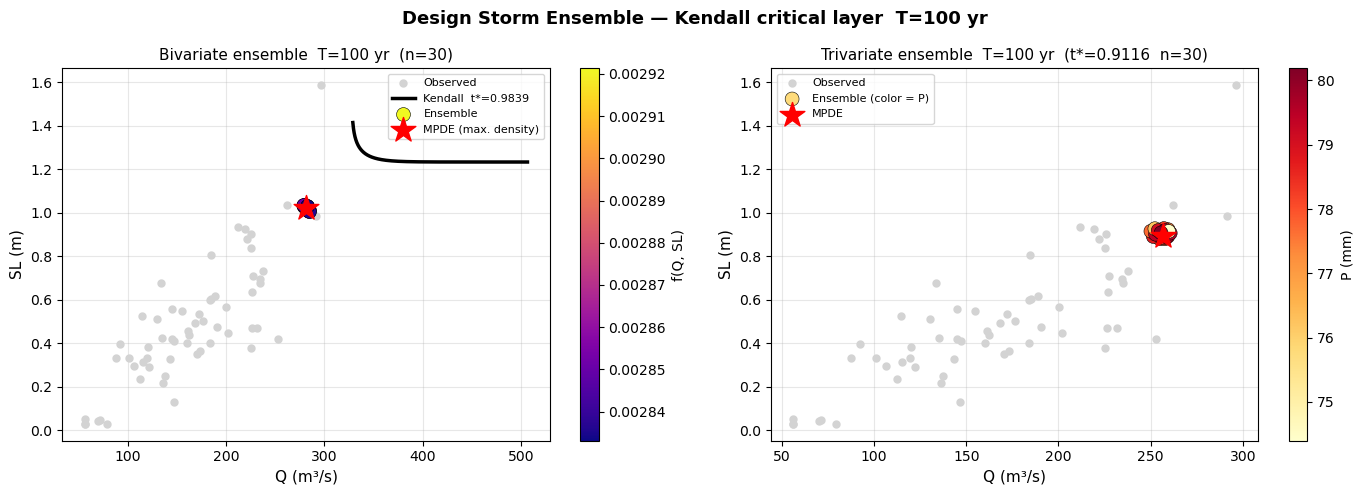


Top-5 bivariate events (highest joint density):
 Q (m³/s)  SL (m)   C_uv  joint_pdf  t_star
 281.6781  1.0209 0.9351     0.0029  0.9839
 282.5560  1.0159 0.9349     0.0029  0.9839
 280.0873  1.0262 0.9347     0.0029  0.9839
 280.9768  1.0243 0.9351     0.0029  0.9839
 280.9128  1.0267 0.9354     0.0029  0.9839

Top-5 trivariate events:
 Q (m³/s)  SL (m)  P (mm)  C3_uvw  joint_pdf  t_star
 256.5432  0.8950 75.7651  0.8669     0.0002  0.9116
 253.1939  0.9054 76.3430  0.8670     0.0002  0.9116
 256.2103  0.9046 76.4295  0.8699     0.0002  0.9116
 255.9256  0.8925 77.6428  0.8694     0.0002  0.9116
 255.4961  0.8990 77.9381  0.8709     0.0002  0.9116


In [29]:
from scipy.optimize import brentq
from IPython.display import display
import matplotlib.lines as mlines

T_ENS = 100

# ── Bivariate ensemble ────────────────────────────────────────────────────────
ens2 = bvcp.design_storm_ensemble(T_ENS, n_events=30, n_sim=150_000, random_state=42)
t2_star = ens2['t_star'].iloc[0]

# Reconstruct Kendall contour from precomputed K function
u_lo_k = float(np.clip(t2_star + 5e-4, 1e-4, 1 - 2e-4))
xk2, yk2 = [], []
for u in np.linspace(u_lo_k, 1 - 1e-4, 300):
    try:
        if bvcp.cdf(u, 1 - 1e-8) < t2_star:
            continue
        vv = brentq(lambda v_: bvcp.cdf(u, v_) - t2_star,
                    1e-8, 1 - 1e-8, xtol=1e-8)
        xk2.append(bvcp.marginal_ppf_x(u))
        yk2.append(bvcp.marginal_ppf_y(vv))
    except Exception:
        pass
xk2, yk2 = np.array(xk2), np.array(yk2)

# ── Trivariate ensemble ───────────────────────────────────────────────────────
ens3 = tvcp.design_storm_ensemble(T_ENS, n_events=30, n_sim=150_000, random_state=42)
t3_star = ens3['t_star'].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(Q, SL, s=25, c='lightgrey', zorder=3, label='Observed')
if len(xk2):
    ax.plot(xk2, yk2, 'k-', lw=2.5, label=f'Kendall  t*={t2_star:.4f}', zorder=4)
sc = ax.scatter(ens2['Q (m³/s)'], ens2['SL (m)'],
                c=ens2['joint_pdf'], cmap='plasma', s=100, zorder=6,
                edgecolors='k', lw=0.4, label='Ensemble')
plt.colorbar(sc, ax=ax, label='f(Q, SL)')
ax.scatter(ens2['Q (m³/s)'].iloc[0], ens2['SL (m)'].iloc[0],
           marker='*', s=350, c='red', zorder=7, label='MPDE (max. density)')
ax.set_xlabel('Q (m³/s)', fontsize=11); ax.set_ylabel('SL (m)', fontsize=11)
ax.set_title(f'Bivariate ensemble  T={T_ENS} yr  (n={len(ens2)})', fontsize=11)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.scatter(Q, SL, s=25, c='lightgrey', zorder=3, label='Observed')
sc2 = ax2.scatter(ens3['Q (m³/s)'], ens3['SL (m)'],
                  c=ens3['P (mm)'], cmap='YlOrRd', s=100, zorder=6,
                  edgecolors='k', lw=0.4, label='Ensemble (color = P)')
plt.colorbar(sc2, ax=ax2, label='P (mm)')
ax2.scatter(ens3['Q (m³/s)'].iloc[0], ens3['SL (m)'].iloc[0],
            marker='*', s=350, c='red', zorder=7, label='MPDE')
ax2.set_xlabel('Q (m³/s)', fontsize=11); ax2.set_ylabel('SL (m)', fontsize=11)
ax2.set_title(f'Trivariate ensemble  T={T_ENS} yr  (t*={t3_star:.4f}  n={len(ens3)})', fontsize=11)
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

fig.suptitle(f'Design Storm Ensemble — Kendall critical layer  T={T_ENS} yr',
             fontsize=13, fontweight='bold')
plt.tight_layout()
display(fig); plt.close(fig)

print("\nTop-5 bivariate events (highest joint density):")
print(ens2.head(5)[['Q (m³/s)', 'SL (m)', 'C_uv', 'joint_pdf', 't_star']].round(4).to_string(index=False))
print("\nTop-5 trivariate events:")
print(ens3.head(5)[['Q (m³/s)', 'SL (m)', 'P (mm)', 'C3_uvw', 'joint_pdf', 't_star']].round(4).to_string(index=False))


#### Coherence between bivariate and trivariate ensembles

| Ensemble | t\* | Q MPDE (m³/s) | SL MPDE (m) | P MPDE (mm) |
|----------|-----|-------------|------------|------------|
| Bivariate (§10 table) | 0.9833 → ensemble 0.9839 | ≈ 264 | ≈ 1.00 | — |
| Trivariate (§10 table) | 0.9115 → ensemble 0.9116 | ≈ 246 | ≈ 0.88 | ≈ 72 |

Both t\* values match the Kendall table within MC noise ✓. The bivariate ensemble clusters tightly at Q ≈ 263–264 m³/s, SL ≈ 0.998–1.007 m — the Kendall isoline is a narrow band in (Q, SL) space for this strongly dependent copula.

**Why is the Kendall MPDE (Q ≈ 264 m³/s, SL ≈ 1.00 m) lower than the OR MPDE (Q ≈ 311 m³/s, SL ≈ 1.34 m) at T = 100 yr?**

These two MPDEs lie on **different isolines**, answering different questions:

- **OR MPDE** (§4): most probable event on the contour `P(Q>q OR SL>sl) = 1/T`, i.e., `{(u,v): 1 − C(u,v) = 1/100}`. This is an *at-least-one-exceedance* envelope.
- **Kendall MPDE** (§10–11): most probable event on the critical layer `{(u,v): C(u,v) = t*}` where `t*` satisfies `K₂(t*) = 1 − 1/T`. The Kendall layer is scenario-neutral.

The ~15 % difference in Q and ~25 % difference in SL reflects that the Kendall threshold `t* = 0.9833` is strictly inside the OR isoline: **the Kendall layer is a less extreme but more risk-coherent reference** because it integrates the joint distribution of C(U,V) rather than conditioning on a specific failure mode. For engineering use, the OR contour defines the *envelope* of concern (useful for warning thresholds), while the Kendall ensemble (rows 0–N in `ens2`) provides a set of physically diverse compound scenarios with the same Kendall risk budget.

**How to use the ensemble for hydraulic modelling:**
1. **Row 0 = MPDE** — deterministic design event for a standard assessment.
2. **Select 3–5 members** spanning the Q/SL trade-off (SL-dominated, balanced, Q-dominated).
3. **Drive the hydraulic model** (SFINCS, HEC-RAS) with each member to produce inundation maps.
4. **Take the depth envelope** across members as the T-year compound hazard map — captures scenario uncertainty the MPDE alone cannot represent.


---
## 12 · Vine Copula — flexible d-dimensional structure

**Vine copulas** (R-vine pair-copula constructions, PCC) generalise exchangeable Archimedean
copulas to multivariate distributions of arbitrary dimension with **asymmetric pair-specific**
dependence structure.

### Differences from Archimedean copulas

| Feature | Archimedean (Gumbel/Clayton/Frank) | R-Vine PCC |
|---|---|---|
| Parameter | Single θ for all pairs | One parameter per tree |
| Families | One global family | Different family per pair |
| Asymmetric dependence | No (exchangeable) | Yes |
| Fitting | Method of moments (τ → θ) | Maximum pseudo-likelihood |
| Library | scipy | pyvinecopulib |

### Joint density (R-vine)

$$f(\mathbf{x}) = \prod_{k=1}^{d} f_{X_k}(x_k)
  \cdot \prod_{\text{tree } j} \prod_{\text{pair } (a,b|\mathcal{D})}
  c_{ab|\mathcal{D}}\!\left(F_{a|\mathcal{D}},\, F_{b|\mathcal{D}}\right)$$

where $\mathcal{D}$ is the conditioning set of the bivariate pair-copula.

### Kendall return period for vines

The Monte Carlo estimator $K_d(t) = P[C(\mathbf{U}) \le t]$ applies directly:
$N$ samples are drawn from the vine, the vine CDF is evaluated at each point,
and $K_d(t^*) = 1 - \mu/T$ is inverted numerically.

> **Note:** requires `pyvinecopulib` (Nagler & Vatter, 2023), included in the
> HYDRA Docker container (`pip install pyvinecopulib`).


Fitting VineCopula  d=3  n=60
  Marginal Q (m³/s):
  Best marginal: gamma  (AIC=665.5)
  Marginal SL (m):
  Best marginal: gev  (AIC=19.4)
  Marginal P (mm):
  Best marginal: gamma  (AIC=545.9)
  Fitted R-vine: <pyvinecopulib.Vinecop> Vinecop model with 3 variables
tree edge conditioned variables conditioning variables var_types 


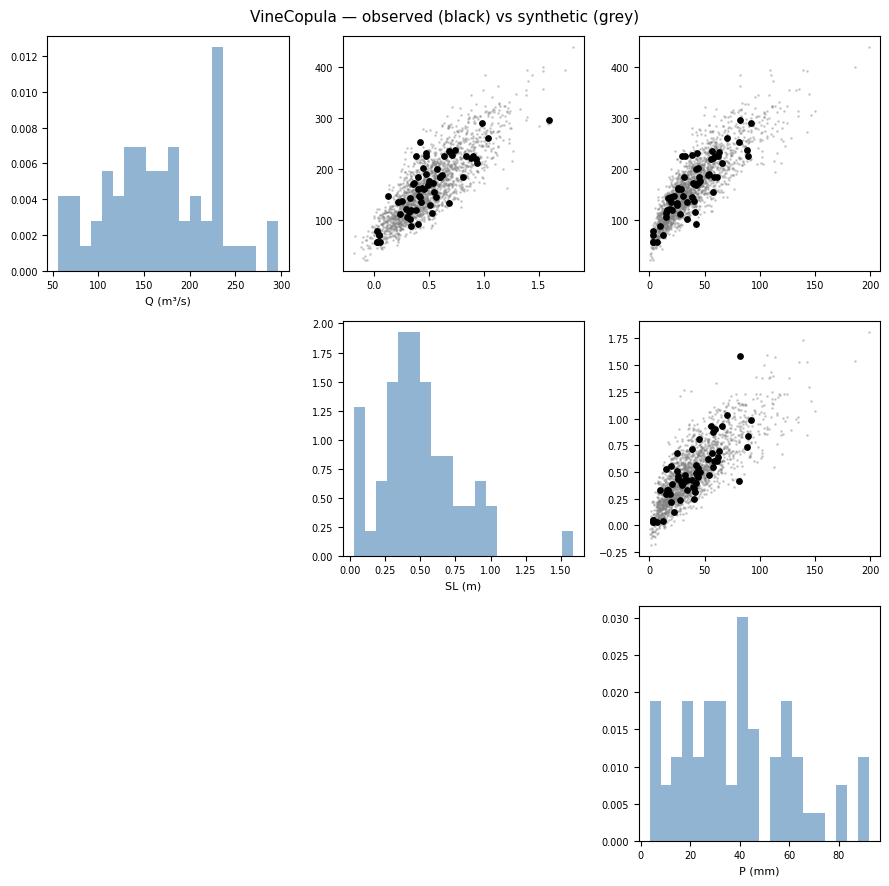


Kendall — VineCopula (d=3)   vs   TrivariateCopula Archimedean
  T (yr)     t* vine     t* arch    K_vine    K_arch
───────────────────────────────────────────────────────
      10      0.7824      0.6330    0.9000    0.9000
      25      0.8951      0.7965    0.9600    0.9600
      50      0.9376      0.8649    0.9800    0.9800
     100      0.9621      0.9115    0.9900    0.9900
     200      0.9775      0.9390    0.9950    0.9950
     500      0.9877      0.9636    0.9980    0.9980

Top-5 VineCopula design events  T=100 yr  (t*=0.9627):
 Q (m³/s)  SL (m)  P (mm)   C_u  log_joint_pdf
  281.376   1.040  90.551 0.916        -10.377
  292.722   1.008  88.539 0.915        -10.410
  290.186   1.020  90.006 0.918        -10.412
  284.376   1.029  93.829 0.920        -10.450
  292.668   0.975  93.345 0.915        -10.460


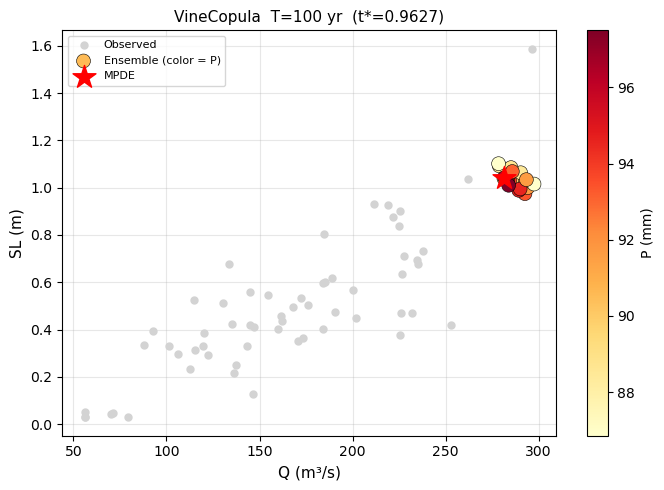

In [30]:
try:
    import pyvinecopulib  # raises ImportError if not installed
    from pyhydra.climate.spatial_analysis import VineCopula
    from IPython.display import display

    # ── Fit vine copula ────────────────────────────────────────────────────
    vc = VineCopula()
    vc.fit(df, labels=['Q (m³/s)', 'SL (m)', 'P (mm)'])

    # ── Scatter matrix ─────────────────────────────────────────────────────
    fig_vm, _ = vc.plot_matrix(n_synthetic=2000, random_state=42)
    fig_vm.suptitle('VineCopula — observed (black) vs synthetic (grey)', fontsize=11)
    fig_vm.tight_layout()
    display(fig_vm); plt.close(fig_vm)

    # ── Kendall critical levels: VineCopula vs Archimedean ─────────────────
    print("\nKendall — VineCopula (d=3)   vs   TrivariateCopula Archimedean")
    print(f"{'T (yr)':>8}  {'t* vine':>10}  {'t* arch':>10}  {'K_vine':>8}  {'K_arch':>8}")
    print('─' * 55)
    t_v, K_v = vc.kendall_function(n_sim=20_000, random_state=0)
    from scipy.interpolate import interp1d as _i1d
    f_inv_v = _i1d(K_v, t_v, kind='linear', bounds_error=False, fill_value=(t_v[0], t_v[-1]))
    for T in [10, 25, 50, 100, 200, 500]:
        target = 1.0 - 1.0 / T
        t_vine = float(f_inv_v(target))
        t_arch = tvcp.kendall_return_period(T, n_sim=20_000, random_state=0)['t_star']
        print(f"{T:>8}  {t_vine:>10.4f}  {t_arch:>10.4f}  {target:>8.4f}  {target:>8.4f}")

    # ── Design storm ensemble ──────────────────────────────────────────────
    ens_v = vc.design_storm_ensemble(T=100, n_events=20, n_sim=50_000, random_state=42)
    mpde_v = ens_v.iloc[0]

    print(f"\nTop-5 VineCopula design events  T=100 yr  (t*={ens_v['t_star'].iloc[0]:.4f}):")
    print(ens_v[['Q (m³/s)', 'SL (m)', 'P (mm)', 'C_u', 'log_joint_pdf']].head(5).round(3).to_string(index=False))

    fig_ve, ax_ve = plt.subplots(figsize=(7, 5))
    ax_ve.scatter(df['Q_m3s'], df['SL_m'], s=25, c='lightgrey', zorder=3, label='Observed')
    sc = ax_ve.scatter(ens_v['Q (m³/s)'], ens_v['SL (m)'],
                       c=ens_v['P (mm)'], cmap='YlOrRd', s=100, zorder=6,
                       edgecolors='k', lw=0.4, label='Ensemble (color = P)')
    plt.colorbar(sc, ax=ax_ve, label='P (mm)')
    ax_ve.scatter(mpde_v['Q (m³/s)'], mpde_v['SL (m)'],
                  marker='*', s=300, c='red', zorder=7, label='MPDE')
    ax_ve.set_xlabel('Q (m³/s)', fontsize=11)
    ax_ve.set_ylabel('SL (m)', fontsize=11)
    ax_ve.set_title(f"VineCopula  T=100 yr  (t*={ens_v['t_star'].iloc[0]:.4f})", fontsize=11)
    ax_ve.legend(fontsize=8); ax_ve.grid(alpha=0.3)
    plt.tight_layout()
    display(fig_ve); plt.close(fig_ve)

except ImportError:
    print("pyvinecopulib is not installed in this environment.")
    print("Install it with:  pip install pyvinecopulib")
    print("The HYDRA Docker container already includes it.")
